In [ ]:
import numpy as np
import pandana as pdna
import geopandas as gpd
import pandas as pd
import osmnx as ox
import math
import networkx as nx
import matplotlib.pyplot as plt
import there

Choose a projected CRS to be used for all distance calculations.

In [3]:
folder = "C:\\Users\\z3258367\\OneDrive - UNSW\\#PhD\\Walkability\\Other Cities\\Colouring data & results\\"
proj_crs = "EPSG:7856"

place = 'Sydney, Australia'
place_gdf = ox.geocode_to_gdf(place).to_crs(proj_crs)

## Import Data

Data sources:
1. OSM POIs
5. Employment data - find govt source

In [4]:
poi_dictionary = there.get_poi_dict()

In [5]:
osm_pois = there.poi_downloader(place_gdf, poi_dictionary, proj_crs)

In [6]:
employment_centrs = gpd.read_file((folder + 
                        "Shared Aus Data\\NSW_Employment_MB_SA1s.gpkg"), layer = 'centroids').to_crs(proj_crs)

employment_centrs['category'] = 'employment'

Need to remove potential overlap between different data sources (and inside some data sources). For now I'm not worrying about this when using only OSM data. Then take this combined POI set and clip it to the study area: should be the same area as is covered by the network. This is important otherwise points outside the network may be erroneously linked to the network.

In [7]:
pois = pd.concat([osm_pois, employment_centrs])

pois = gpd.clip(pois, place_gdf.to_crs(proj_crs))

c:\Users\z3258367\Anaconda3\envs\ox_ua\lib\site-packages\geopandas\array.py:1406: UserWarning: CRS not set for some of the concatenation inputs. Setting output's CRS as GDA2020 / MGA zone 56 (the single non-null crs provided).
  warnings.warn(


### POI parameters

Choose drive index weightings, and output the sums of each category and the total to check. The drive index will be out of 100 regardless of this sum, but it is important to note that eg. shopping is only '10% of the walk index' if shopping is 10 out of 100.

In [ ]:
poi_parameters = there.default_poi_params()
poi_parameters = poi_parameters.sort_index()

poi_weights = poi_parameters['weight'].copy()
poi_lambdas = poi_parameters['diminishing_returns_constant'].copy()
poi_variables = poi_parameters['variable'].copy()
poi_nums = poi_parameters['num_pois'].copy()
poi_gammas = poi_parameters['distance_constant'].copy()

total = sum(poi_weights)
print("total: ", total)

total:  100.0


In [9]:
# change this to match the column containing job counts in employment dataframe
poi_variables.loc['employment'] = 'Jobs'
# change this to make employment score more accurate (higher number) or to reduce index calculation time (low number)
poi_nums.loc['employment'] = 1200

## Walking

In [10]:
walk_dist=2400

In [11]:
walk_network = there.prepare_walk_net(place_gdf, proj_crs)

In [24]:
%%capture --no-stdout 
#hides FutureWarning related to Pandana. turn off if something is not working.

results_walk_cluster5, result_pois_5 = there.cluster_index(walk_network, pois, poi_dictionary, poi_weights, poi_gammas,
                            poi_nums, poi_lambdas, poi_variables, distance=walk_dist, loop=5, chain_frac=1/3, trace=True)   

Finished category: education
Maximum score: 6.010013822430037 out of 14.3
Finished category: employment
Maximum score: 13.146624570555062 out of 31.9
Finished category: errands
Maximum score: 4.3807615043319155 out of 8.9
Finished category: recreation
Maximum score: 11.501011811249201 out of 23.3
Finished category: shopping
Maximum score: 10.661356395967015 out of 21.6
loop: 0
Finished category: education
Maximum score: 6.86105517199051 out of 14.3
Finished category: employment
Maximum score: 15.842908037030941 out of 31.9
Finished category: errands
Maximum score: 5.169992782921615 out of 8.9
Finished category: recreation
Maximum score: 13.778611370062643 out of 23.3
Finished category: shopping
Maximum score: 12.635330376840216 out of 21.6
loop: 1
Finished category: education
Maximum score: 7.02436987442293 out of 14.3
Finished category: employment
Maximum score: 16.391403342798927 out of 31.9
Finished category: errands
Maximum score: 5.354319504030412 out of 8.9
Finished category: rec

In [30]:
%%capture --no-stdout 
#hides FutureWarning related to Pandana. turn off if something is not working.

results_walk_cluster0, result_pois_0 = there.cluster_index(walk_network, pois, poi_dictionary, poi_weights, poi_gammas,
                            poi_nums, poi_lambdas, poi_variables, distance=walk_dist, loop=1, chain_frac=0, trace=True)

Finished category: education
Maximum score: 9.015020733645054 out of 14.3
Finished category: employment
Maximum score: 19.719936855832586 out of 31.9
Finished category: errands
Maximum score: 6.571142256497871 out of 8.9
Finished category: recreation
Maximum score: 17.2515177168738 out of 23.3
Finished category: shopping
Maximum score: 15.992034593950518 out of 21.6
loop: 0


In [28]:
results_walk_cluster5['change1'] = results_walk_cluster5[('THERE_' + str(1))] - results_walk_cluster5[('THERE_' + str(0))]
results_walk_cluster5['change2'] = results_walk_cluster5[('THERE_' + str(2))] - results_walk_cluster5[('THERE_' + str(1))]
results_walk_cluster5['change3'] = results_walk_cluster5[('THERE_' + str(3))] - results_walk_cluster5[('THERE_' + str(2))]
results_walk_cluster5['change4'] = results_walk_cluster5[('THERE_' + str(4))] - results_walk_cluster5[('THERE_' + str(3))]
results_walk_cluster5['propchange1'] = results_walk_cluster5['change1']/results_walk_cluster5[('THERE_' + str(0))]*100
results_walk_cluster5['propchange2'] = results_walk_cluster5['change2']/results_walk_cluster5[('THERE_' + str(1))]*100
results_walk_cluster5['propchange3'] = results_walk_cluster5['change3']/results_walk_cluster5[('THERE_' + str(2))]*100
results_walk_cluster5['propchange4'] = results_walk_cluster5['change4']/results_walk_cluster5[('THERE_' + str(3))]*100

In [51]:
# generate summary table where rows are columns THERE_0 to THERE_9, with max, mean, and % change from previous
results_walk_cluster5.loc[:,'THERE_0':'percent_diff3'].describe().T

,count,mean,std,min,25%,50%,75%,max
THERE_0,301699.0,16.639329,7.333837,0.000000e+00,11.905305,16.127912,21.145467,42.129077
THERE_1,301699.0,18.489378,8.630054,0.000000e+00,12.829694,17.651682,23.601818,50.868941
THERE_2,301699.0,18.720499,8.846164,0.000000e+00,12.911262,17.808542,23.902669,52.667487
THERE_3,301699.0,18.751801,8.882104,0.000000e+00,12.920062,17.825439,23.939572,53.035632
THERE_4,301699.0,18.756312,8.888178,0.000000e+00,12.920943,17.827371,23.944554,53.110700
change1,301699.0,1.850049,1.342831,0.000000e+00,0.923239,1.527305,2.469087,8.739864
change2,301699.0,0.231122,0.236958,0.000000e+00,0.079421,0.156642,0.301349,1.798545
change3,301699.0,0.031302,0.042415,0.000000e+00,0.007314,0.016912,0.038233,0.368146
change4,301699.0,0.004510,0.007780,0.000000e+00,0.000697,0.001894,0.004947,0.075067
propchange1,300168.0,9.810525,3.218756,4.017370e-04,7.815228,9.586935,11.821885,20.745444


In [40]:
results_walk_cluster5['nocluster'] = results_walk_cluster0['THERE_Index']
results_walk_cluster5['diff4'] = results_walk_cluster5['nocluster'] - results_walk_cluster5[('THERE_' + str(4))]
results_walk_cluster5['diff3'] = results_walk_cluster5['nocluster'] - results_walk_cluster5[('THERE_' + str(3))]
results_walk_cluster5['percent_diff4'] = results_walk_cluster5['diff4']/results_walk_cluster5['nocluster']
results_walk_cluster5['percent_diff3'] = results_walk_cluster5['diff3']/results_walk_cluster5['nocluster']

### Visual

In [32]:
import matplotlib_scalebar 
from matplotlib_scalebar.scalebar import ScaleBar
from shapely.geometry import Point
from matplotlib.ticker import PercentFormatter

In [33]:
envelope = result_pois_5.to_crs("EPSG:4326").unary_union.envelope
envelope = gpd.GeoDataFrame({'geometry': envelope, 'convex_hull':[1]},crs=proj_crs)
graph_envelope = gpd.GeoDataFrame({'geometry': result_pois_5.to_crs("EPSG:4326").unary_union.envelope, 'convex_hull':[1]},crs="EPSG:4326")

In [34]:
Australia = gpd.read_file("C:\\Users\\z3258367\\OneDrive - UNSW\\#PhD\\Data\\ABS Data\\2016_GCCSA_aust_shape\\GCCSA_2016_AUST.shp").to_crs(proj_crs)
graph_area = Australia.to_crs("EPSG:4326")
graph_area = graph_area.clip(graph_envelope)

c:\Users\z3258367\Anaconda3\envs\ox_ua\lib\site-packages\geopandas\tools\clip.py:67: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  clipped.loc[


In [35]:
# option to use every third row to speed up plotting. The maps are still considerably over-plotted, for large cities at this figure size.
points = gpd.GeoSeries([Point(150, -33.8), Point(151, -33.8)], crs=4326)  # Geographic WGS 84 - degrees
points = points.to_crs(32619) # Projected WGS 84 - meters
distance_meters = points[0].distance(points[1])

In [49]:
loops = [0,0,0]

results_gdf =  gpd.GeoDataFrame(results_walk_cluster0, 
                                    geometry = gpd.GeoSeries.from_xy(results_walk_cluster0.x, results_walk_cluster0.y, crs=proj_crs))
graph_data = results_gdf.iloc[::3, :].to_crs("EPSG:4326")
graph_pois = result_pois_0.to_crs("EPSG:4326")

results_gdf_5 =  gpd.GeoDataFrame(results_walk_cluster5, 
                                    geometry = gpd.GeoSeries.from_xy(results_walk_cluster5.x, results_walk_cluster5.y, crs=proj_crs))
graph_data_5 = results_gdf_5.iloc[::3, :].to_crs("EPSG:4326")
graph_pois_5 = result_pois_5.to_crs("EPSG:4326")

vmin = min(graph_pois_5['THERE_4'].min(), graph_data['THERE_Index'].min())
vmax = max(graph_pois_5['THERE_4'].max(), graph_data['THERE_Index'].max())


In [47]:
envelope.bounds

,minx,miny,maxx,maxy
0,150.264951,-34.165924,151.341577,-33.367601


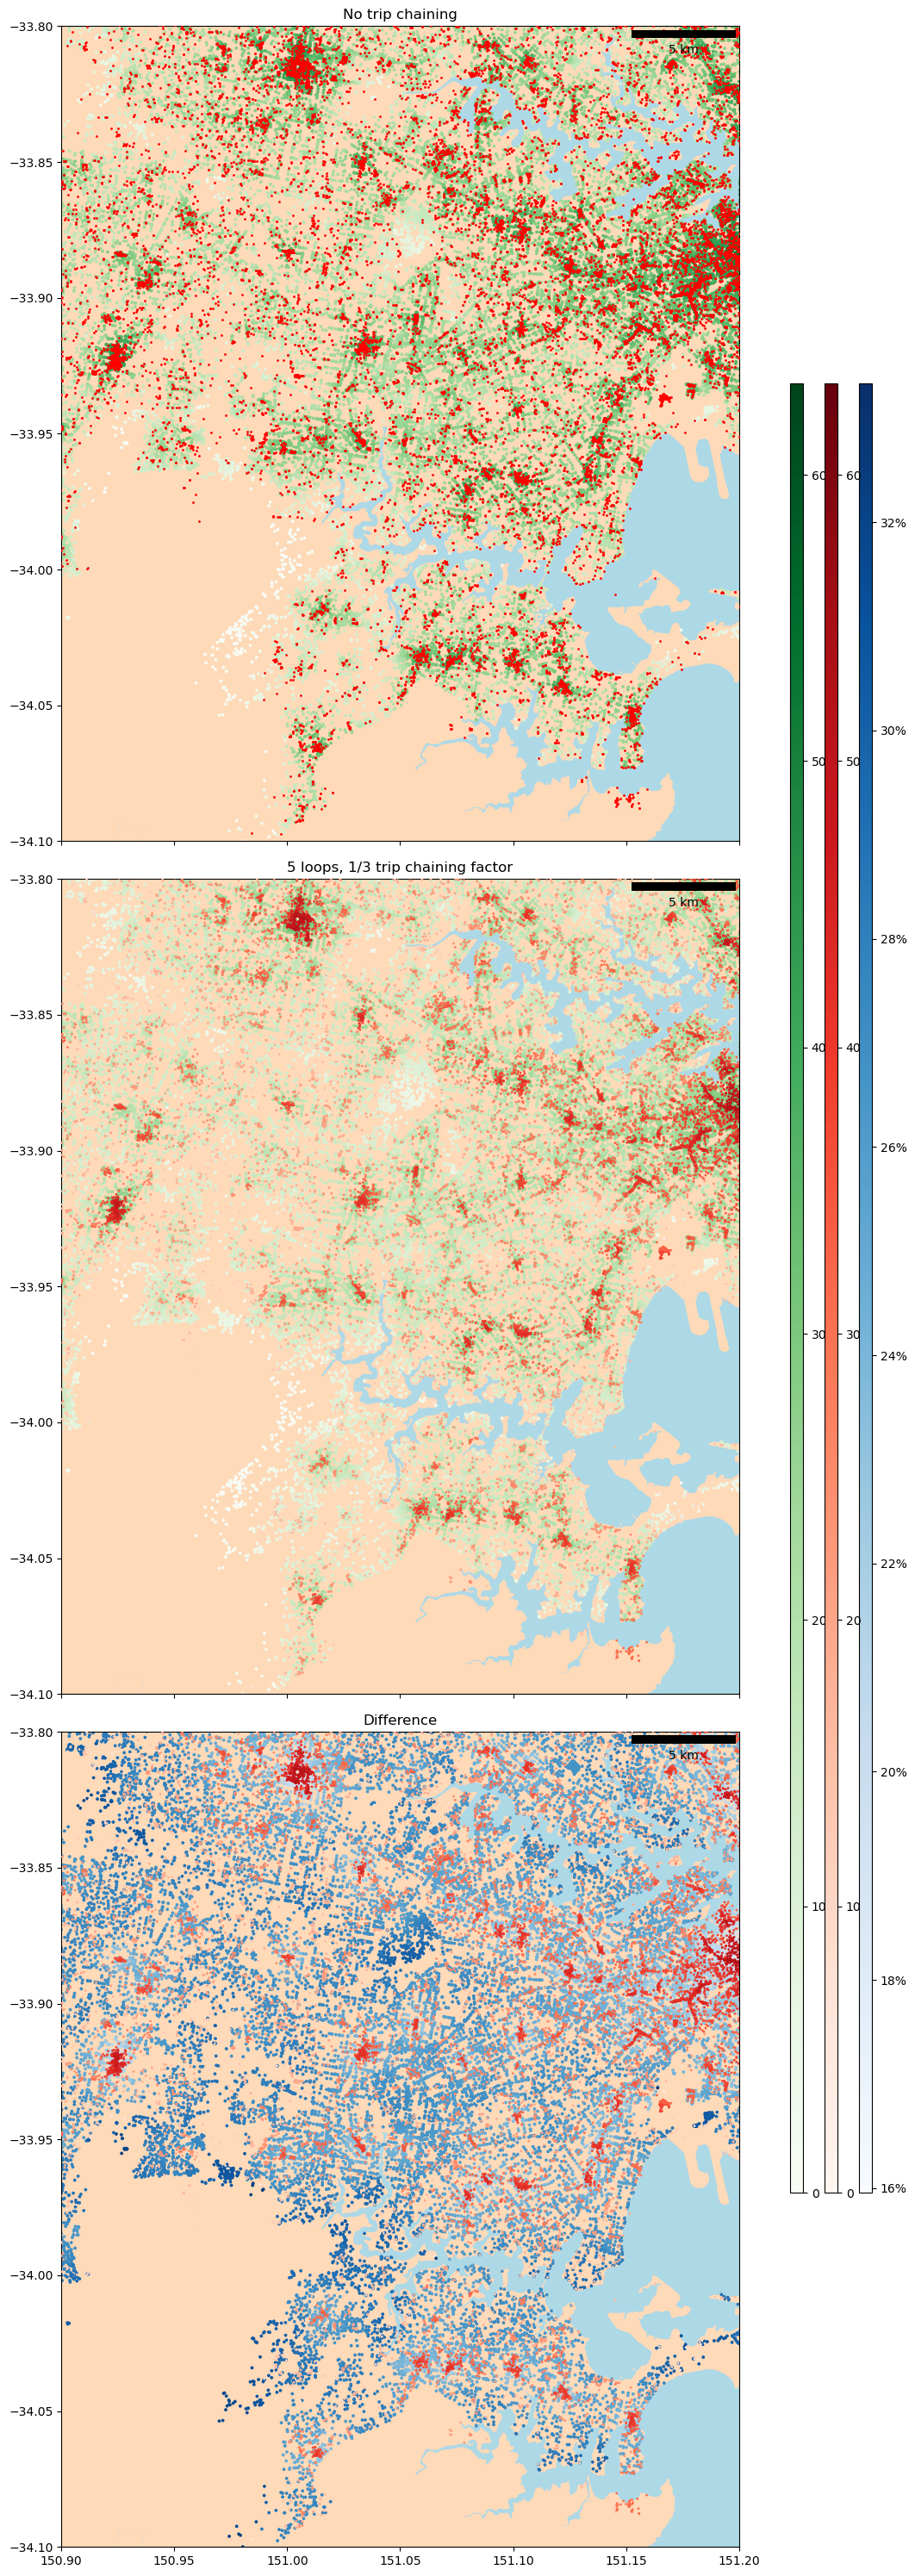

In [50]:
fig, axs = plt.subplots(len(loops),1, sharex=True, sharey=True, 
                       subplot_kw=dict(facecolor="lightblue",xmargin=0,ymargin=0), 
                       figsize=(10,30))

for ax in axs.ravel():
    graph_area.plot(ax = ax, zorder=1, color='peachpuff')
    ax.add_artist(ScaleBar(distance_meters, frameon=False))
    ax.set_xlim([150.9, 151.2])
    ax.set_ylim([-34.1, -33.8])

# put overall index in the first subplot
graph_data.plot(ax = axs[0], zorder=2, column= "THERE_Index", 
                     cmap='Greens', markersize=3, vmin=vmin, vmax=vmax)
graph_pois.plot(ax = axs[0], zorder=3, color='red', markersize=1)
axs[0].set_title("No trip chaining")

# index after 5 rounds
graph_data_5.plot(ax = axs[1], zorder=2, column= "THERE_Index", 
                     cmap='Greens', markersize=3, vmin=vmin, vmax=vmax)
graph_pois_5.plot(ax = axs[1], zorder=3, column = "THERE_4", cmap='Reds', markersize=1)
axs[1].set_title("5 loops, 1/3 trip chaining factor")

# difference
graph_data_5.plot(ax = axs[2], zorder=2,
                    column = 'percent_diff4',
                    cmap='Blues', markersize=3)
graph_pois_5.plot(ax = axs[2], zorder=3, column = "THERE_4", cmap='Reds', markersize=1)
axs[2].set_title("Difference")
    
plt.tight_layout()

# Create colorbar scale
sm = plt.cm.ScalarMappable(cmap='Greens', norm=plt.Normalize(vmin=vmin, vmax=vmax))
 # empty array for the data range
sm._A = []
# add the colorbar to the figure
fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.91,0.15,0.015,0.7])
fig.colorbar(sm, cax=cbar_ax)

# Create colorbar scale
sm2 = plt.cm.ScalarMappable(cmap='Blues', norm=plt.Normalize(graph_data_5['percent_diff4'].min(), graph_data_5['percent_diff4'].max()))
 # empty array for the data range
sm2._A = []
# add the colorbar to the figure
cbar_ax2 = fig.add_axes([0.99,0.15,0.015,0.7])
#cbar = cbar_ax2.collections[0].colorbar
#cbar.ax.yaxis.set_major_formatter(PercentFormatter(1, 0))
fig.colorbar(sm2, cax=cbar_ax2)
cbar_ax2.yaxis.set_major_formatter(PercentFormatter(1, 0))

# Create colorbar scale
sm3 = plt.cm.ScalarMappable(cmap='Reds', norm=plt.Normalize(vmin=vmin, vmax=vmax))
 # empty array for the data range
sm3._A = []
# add the colorbar to the figure
cbar_ax3 = fig.add_axes([0.95,0.15,0.015,0.7])
#cbar = cbar_ax2.collections[0].colorbar
#cbar.ax.yaxis.set_major_formatter(PercentFormatter(1, 0))
fig.colorbar(sm3, cax=cbar_ax3)
cbar_ax2.yaxis.set_major_formatter(PercentFormatter(1, 0))

# 2. Driving

In [15]:
drive_gammas = poi_gammas.copy()
drive_gammas = drive_gammas.replace(to_replace=0.001, value=0.000075)
drive_dist=24000

In [16]:
# Create a pandana network with data extracted from an OSMNX graph
drive_network = there.prepare_drive_net(place_gdf, proj_crs)

In [17]:
%%capture --no-stdout 

results_drive_cluster0 = there.cluster_index(drive_network, pois, poi_dictionary, poi_weights, drive_gammas,
                            poi_nums, poi_lambdas, poi_variables, distance=drive_dist, loop=1)
results_drive_cluster3 = there.cluster_index(drive_network, pois, poi_dictionary, poi_weights, drive_gammas,
                            poi_nums, poi_lambdas, poi_variables, distance=drive_dist, chain_frac=0.3, prev_results=results_drive_cluster0)
results_drive_cluster5 = there.cluster_index(drive_network, pois, poi_dictionary, poi_weights, drive_gammas,
                            poi_nums, poi_lambdas, poi_variables, distance=drive_dist, chain_frac=0.5, prev_results=results_drive_cluster0)

Finished category: education
Maximum score: 10.46714021976079 out of 14.3
Finished category: employment
Maximum score: 30.109039363753723 out of 31.9
Finished category: errands
Maximum score: 6.588875470920308 out of 8.9
Finished category: recreation
Maximum score: 17.2515177168738 out of 23.3
Finished category: shopping
Maximum score: 15.992823291179144 out of 21.6
Finished category: education
Maximum score: 9.729355533491775 out of 14.3
Finished category: employment
Maximum score: 28.25167640313779 out of 31.9
Finished category: errands
Maximum score: 6.187616582211688 out of 8.9
Finished category: recreation
Maximum score: 16.20701316430197 out of 23.3
Finished category: shopping
Maximum score: 15.013184823248563 out of 21.6
Finished category: education
Maximum score: 9.275799481292097 out of 14.3
Finished category: employment
Maximum score: 27.01343442939394 out of 31.9
Finished category: errands
Maximum score: 5.92098698649526 out of 8.9
Finished category: recreation
Maximum score

In [18]:
# sanity check
print(max(results_drive_cluster0['THERE_Index']), np.mean(results_drive_cluster0['THERE_Index']))
print(max(results_drive_cluster3['THERE_Index']), np.mean(results_drive_cluster3['THERE_Index']))
print(max(results_drive_cluster5['THERE_Index']), np.mean(results_drive_cluster5['THERE_Index']))

79.88595808480633 64.4382395769139
75.00260465828352 58.03468908817782
71.74703570726832 53.76565542902043


# 3. Cycling

In [19]:
cycle_gammas = poi_gammas.copy()
cycle_gammas = cycle_gammas.replace(to_replace=0.001, value=0.0002)
cycle_dist = 12000

In [20]:
cycle_network = there.prepare_cycle_net(place_gdf, proj_crs)

In [21]:
%%capture --no-stdout 
#hides FutureWarning related to Pandana. turn off if something is not working.
results_cycle_cluster0 = there.cluster_index(cycle_network, pois, poi_dictionary, poi_weights, cycle_gammas,
                            poi_nums, poi_lambdas, poi_variables, distance=cycle_dist, loop=1)
results_cycle_cluster3 = there.cluster_index(cycle_network, pois, poi_dictionary, poi_weights, cycle_gammas,
                            poi_nums, poi_lambdas, poi_variables, distance=cycle_dist, chain_frac=0.3, prev_results=results_cycle_cluster0)
results_cycle_cluster5 = there.cluster_index(cycle_network, pois, poi_dictionary, poi_weights, cycle_gammas,
                            poi_nums, poi_lambdas, poi_variables, distance=cycle_dist, chain_frac=0.5, prev_results=results_cycle_cluster0)     

Finished category: education
Maximum score: 9.570249495412972 out of 14.3
Finished category: employment
Maximum score: 26.67499890945038 out of 31.9
Finished category: errands
Maximum score: 6.584130529707969 out of 8.9
Finished category: recreation
Maximum score: 17.251473651718136 out of 23.3
Finished category: shopping
Maximum score: 15.992823291179144 out of 21.6
Finished category: education
Maximum score: 8.442212805641809 out of 14.3
Finished category: employment
Maximum score: 24.173276764406477 out of 31.9
Finished category: errands
Maximum score: 5.946985775474379 out of 8.9
Finished category: recreation
Maximum score: 15.769762787071679 out of 23.3
Finished category: shopping
Maximum score: 14.343707498147781 out of 21.6
Finished category: education
Maximum score: 7.7316249603190315 out of 14.3
Finished category: employment
Maximum score: 22.50546200104389 out of 31.9
Finished category: errands
Maximum score: 5.5914388029849205 out of 8.9
Finished category: recreation
Maximum

In [22]:
print(max(results_cycle_cluster0['THERE_Index']), np.mean(results_cycle_cluster0['THERE_Index']))
print(max(results_cycle_cluster3['THERE_Index']), np.mean(results_cycle_cluster3['THERE_Index']))
print(max(results_cycle_cluster5['THERE_Index']), np.mean(results_cycle_cluster5['THERE_Index']))

73.15725907274098 33.47389592111163
66.65000717394257 27.523368913840315
62.31183924141029 23.556350908992776


# 4. Transit

In [12]:
gtfs_path='C:\\Users\\z3258367\\OneDrive - UNSW\\#PhD\\' + 'Data\\TfNSW\\'  + "full_greater_sydney_gtfs_static_15.12"

In [13]:
# earlier results were with gamma 0.025, but have now changed to 0.05.
wgs_pois = pois.to_crs("EPSG:4326")
transit_max_time = 90


In [14]:
urbanaccess_net = there.prepare_transit_net(place_gdf, proj_crs, gtfs_path, walk_network)

Checking GTFS text file header whitespace... Reading files using encoding: utf-8 set in configuration.
GTFS text file header whitespace check completed. Took 2.77 seconds
--------------------------------
Processing GTFS feed: full_greater_sydney_gtfs_static_15.12


c:\Users\z3258367\Anaconda3\envs\ox_ua\lib\site-packages\urbanaccess\gtfs\utils_format.py:1066: FutureWarning: The default value of regex will change from True to False in a future version.
  col_snake_case = col.str.replace(r'\s+', '_')


GTFS feed: full_greater_sydney_gtfs_static_15.12, calendar_dates uses the same service_id across multiple agency_ids. This feed calendar_dates table will be modified from its original format to provide service_ids for each agency using a one to many join


c:\Users\z3258367\Anaconda3\envs\ox_ua\lib\site-packages\urbanaccess\gtfs\utils_format.py:1066: FutureWarning: The default value of regex will change from True to False in a future version.
  col_snake_case = col.str.replace(r'\s+', '_')


GTFS feed: full_greater_sydney_gtfs_static_15.12, calendar uses the same service_id across multiple agency_ids. This feed calendar table will be modified from its original format to provide service_ids for each agency using a one to many join


...

agency.txt agency_name column has more than one agency name listed. Unique agency id was assigned using the agency id and associated agency name.
Unique agency id operation complete. Took 42.80 seconds
Unique GTFS feed id operation complete. Took 0.04 seconds
Records:
       stop_id                 unique_agency_id  stop_code  \
326     253330                              nan        NaN   
327     253331  train_replacement_bus_operators   253331.0   
328     253331          kennedy's_bus_and_coach   253331.0   
329     253331                premier_illawarra   253331.0   
330     253331                 kiama_coachlines   253331.0   
...        ...                              ...        ...   
122363  G37403                              nan        NaN   
122364  G37407                              nan        NaN   
122365  G37408                              nan        NaN   
122366  G39004                              nan        NaN   
122367  G47788                              nan  

c:\Users\z3258367\Anaconda3\envs\ox_ua\lib\site-packages\urbanaccess\gtfs\network.py:744: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for trip, tmp_trip_df in stop_times_df.groupby(['unique_trip_id']):


stop time table transformation to Pandana format edge table completed. Took 38.10 seconds
Time conversion completed: seconds converted to minutes.
27,215 of 55,240 records selected from stops. Took 0.14 seconds
stop time table transformation to Pandana format node table completed. Took 0.02 seconds
route type successfully joined to transit edges. Took 8.04 seconds
route id successfully joined to transit edges. Took 0.54 seconds
Successfully created transit network. Took 54.42 seconds
Stop times from 07:00:00 to 12:00:00 successfully selected 717,599 records out of 2,261,672 total records (31.73 percent of total). Took 0.10 seconds
Starting route stop headway calculation for 58,730 route stops...
Route stop headway calculation complete. Took 113.58 seconds
headway calculation complete. Took 119.52 seconds
Created OSM network with travel time impedance using a travel speed of 1.875 MPH. Took 0.02 seconds
Loaded UrbanAccess network components comprised of:
     Transit: 27,215 nodes and 6

c:\Users\z3258367\Anaconda3\envs\ox_ua\lib\site-packages\geopandas\array.py:1406: UserWarning: CRS not set for some of the concatenation inputs. Setting output's CRS as WGS 84 (the single non-null crs provided).
  warnings.warn(


Edge and node tables formatted for Pandana with integer node ids: id_int, to_int, and from_int. Took 6.21 seconds
Network edge and node network integration completed successfully resulting in a total of 360,412 nodes and 2,340,669 edges:
     Transit: 58,713 nodes 691,917 edges;
     OSM: 301,699 nodes 872,460 edges; and
     OSM/Transit connector: 776,292 edges.


In [16]:
urbanaccess_net.net_edges = there.network.transit_cost(urbanaccess_net.net_edges)
urbanaccess_net.net_edges['adjusted_weight'] = urbanaccess_net.net_edges['weight'] * urbanaccess_net.net_edges['adjustment']

In [17]:
urbanaccess_net.net_edges[['weight','adjustment', 'adjusted_weight', 'net_type']].groupby("net_type").median()

,weight,adjustment,adjusted_weight
net_type,,,
osm to transit,6.239266,1.2,7.487120
transit,1.000000,1.0,1.000000
transit to osm,0.335584,2.0,0.671168
walk,0.857574,2.0,1.715148


In [18]:
urbanaccess_net.net_edges[urbanaccess_net.net_edges['net_type'] == 'walk']['adjustment'] = 2
urbanaccess_net.net_edges['adjusted_weight'] = urbanaccess_net.net_edges['weight'] * urbanaccess_net.net_edges['adjustment']

In [19]:
transit_ped_net, osm_net = there.network.pandana_transit_net(urbanaccess_net, place_gdf)

In [20]:
transit_lambdas = poi_lambdas.copy()
transit_lambdas.loc['education'] = 0.1
transit_lambdas.loc['errands'] = 0.1
transit_lambdas.loc['shopping'] = 0.1
transit_lambdas.loc['recreation'] = 0.1

In [21]:
transit_nums = poi_nums.copy()
transit_nums.loc['employment'] = 600
transit_nums.loc['education'] = 50
transit_nums.loc['errands'] = 50
transit_nums.loc['shopping'] = 50
transit_nums.loc['recreation'] = 50

In [22]:
# need to change the distance/time decay
transit_gammas = poi_gammas.copy()
transit_gammas = transit_gammas.replace(to_replace=0.001, value=0.02)

In [23]:
transit_gammas, poi_gammas, transit_lambdas

(category
 education     0.02
 employment    0.02
 errands       0.02
 recreation    0.02
 shopping      0.02
 Name: distance_constant, dtype: float64,
 category
 education     0.001
 employment    0.001
 errands       0.001
 recreation    0.001
 shopping      0.001
 Name: distance_constant, dtype: float64,
 category
 education     0.100000
 employment    0.000017
 errands       0.100000
 recreation    0.100000
 shopping      0.100000
 Name: diminishing_returns_constant, dtype: float64)

In [25]:
%%capture --no-stdout 
#hides FutureWarning related to Pandana. turn off if something is not working.

results_transit_cluster5, result_transit_pois_5 = there.transit_cluster_index(osm_net, transit_ped_net, wgs_pois, poi_dictionary, poi_weights, transit_gammas, 
                            poi_nums, poi_lambdas, poi_variables, transit_max_time, loop=5, chain_frac=1/3, trace=True)  

Finished category: education
Maximum score: 10.025811701247859 out of 14.3
Finished category: employment
Maximum score: 23.453181104149486 out of 31.9
Finished category: errands
Maximum score: 6.5557215890011244 out of 8.9
Finished category: recreation
Maximum score: 17.2515177168738 out of 23.3
Finished category: shopping
Maximum score: 15.991819898907336 out of 21.6
loop: 0
Finished category: education
Maximum score: 8.591227994942033 out of 14.3


KeyboardInterrupt: 

In [203]:
transit_results02_cluster0 = there.transit_cluster_index(osm_net, transit_ped_net, wgs_pois, poi_dictionary, poi_weights, transit_gammas, poi_nums, poi_lambdas, poi_variables, transit_max_time, loop=1)
print(max(transit_results02_cluster0['THERE_Index']), np.mean(transit_results02_cluster0['THERE_Index']))

Finished category: education
Maximum score: 10.121352724595289 out of 14.3
Finished category: employment
Maximum score: 23.943679976032715 out of 31.9
Finished category: errands
Maximum score: 6.556592685132785 out of 8.9
Finished category: recreation
Maximum score: 17.2515177168738 out of 23.3
Finished category: shopping
Maximum score: 15.991819898907336 out of 21.6
71.02557930571075 48.75515897906165


74.44062036341147 25.66274616672522


In [ ]:
transit_results_cluster0 = there.transit_cluster_index(transit_ped_net, osm_net, wgs_pois, poi_dictionary, poi_weights, transit_gammas, transit_nums, transit_lambdas, poi_variables, transit_max_time, loop=1)
print(max(transit_results_cluster0['THERE_Index']), np.mean(transit_results_cluster0['THERE_Index']))

Finished category: education
Maximum score: 10.438951203497655 out of 14.3
Finished category: employment
Maximum score: 27.224025212953325 out of 31.9
Finished category: errands
Maximum score: 7.8373107847615815 out of 8.9
Finished category: recreation
Maximum score: 20.899383433261438 out of 23.3
Finished category: shopping
Maximum score: 19.285279766190133 out of 21.6
81.91316811476126 34.863103232730296


In [168]:
print(max(results_walk_cluster0['THERE_Index']), np.mean(results_walk_cluster0['THERE_Index']))

68.22943555977037 22.35040945113347


In [94]:
transit_results_cluster0 = there.transit_cluster_index(transit_ped_net, osm_net, wgs_pois, poi_dictionary, poi_weights, transit_gammas, transit_nums, transit_lambdas, poi_variables, transit_max_time, loop=1)

Finished category: education
Maximum score: 10.438951203497655 out of 14.3
Finished category: employment
Maximum score: 27.224025212953325 out of 31.9
Finished category: errands
Maximum score: 7.8373107847615815 out of 8.9
Finished category: recreation
Maximum score: 20.899383433261438 out of 23.3
Finished category: shopping
Maximum score: 19.285279766190133 out of 21.6


In [95]:
print(max(transit_results_cluster0['THERE_Index']), np.mean(transit_results_cluster0['THERE_Index']))
#print(max(transit_results_cluster3['THERE_Index']), np.mean(transit_results_cluster3['THERE_Index']))
#print(max(transit_results_cluster5['THERE_Index']), np.mean(transit_results_cluster5['THERE_Index']))

81.91316811476126 34.863103232730296
57.58226091969533 17.79212702420973
52.98225578118461 14.823397059860145


In [213]:
transit_results_cluster0 = there.transit_cluster_index(osm_net, transit_ped_net, wgs_pois, poi_dictionary, poi_weights, transit_gammas, poi_nums, poi_lambdas, poi_variables, transit_max_time, loop=1)
transit_results_cluster3 = there.transit_cluster_index(osm_net, transit_ped_net, wgs_pois, poi_dictionary, poi_weights, transit_gammas, poi_nums, poi_lambdas, poi_variables, transit_max_time, loop=2, chain_frac=0.3,
                                                       prev_results = transit_results_cluster0)
transit_results_cluster5 = there.transit_cluster_index(osm_net, transit_ped_net, wgs_pois, poi_dictionary, poi_weights, transit_gammas, poi_nums, poi_lambdas, poi_variables, transit_max_time, loop=2, chain_frac=0.5,
                                                       prev_results = transit_results_cluster0)


Finished category: education
Maximum score: 10.025811701247859 out of 14.3
Finished category: employment
Maximum score: 23.453181104149486 out of 31.9
Finished category: errands
Maximum score: 6.5557215890011244 out of 8.9
Finished category: recreation
Maximum score: 17.2515177168738 out of 23.3
Finished category: shopping
Maximum score: 15.991819898907336 out of 21.6
Finished category: education
Maximum score: 8.713808478460919 out of 14.3
Finished category: employment
Maximum score: 20.982526474934282 out of 31.9
Finished category: errands
Maximum score: 5.9292595895486935 out of 8.9
Finished category: recreation
Maximum score: 15.449266657164523 out of 23.3
Finished category: shopping
Maximum score: 14.32860857610654 out of 21.6
Finished category: education
Maximum score: 8.009572098527443 out of 14.3
Finished category: employment
Maximum score: 19.33542338879083 out of 31.9
Finished category: errands
Maximum score: 5.5116182565804035 out of 8.9
Finished category: recreation
Maximum

In [214]:
print(max(transit_results_cluster0['THERE_Index']), np.mean(transit_results_cluster0['THERE_Index']))
print(max(transit_results_cluster3['THERE_Index']), np.mean(transit_results_cluster3['THERE_Index']))
print(max(transit_results_cluster5['THERE_Index']), np.mean(transit_results_cluster5['THERE_Index']))

69.93262833257299 46.00584624225918
62.85589484767324 39.67026079045339
58.17256657318049 35.44653715591622


In [ ]:
print(max(transit_results_cluster0['THERE_Index']), np.mean(transit_results_cluster0['THERE_Index']))
print(max(transit_results_cluster3['THERE_Index']), np.mean(transit_results_cluster3['THERE_Index']))
print(max(transit_results_cluster5['THERE_Index']), np.mean(transit_results_cluster5['THERE_Index']))

66.21472345211023 25.417224225141513
57.62462415453961 18.21365203307974
53.02451599807209 15.19770039396408


In [217]:
35.4/46

0.7695652173913043

## Export results

In [96]:
output = 'C:\\Users\\z3258367\\OneDrive - UNSW\\#PhD\\Walkability\\Other Cities\\Open-Walk-Index\\Clustering\\'
area = 'Sydney'

Reduce the number of decimal places before export, distances do not need to be below 1m.

In [97]:
def result_rounding(results):
    # reduces results size for export
    # score columns such as there.there_index, employment_subtotal etc -> 3 decimal places
    # distance columns such as employment1 -> 0 decimal places (nearest metre)
    # avoid doing anything to connect_id, x or y
    rounding_dict = {**{k:3 for k in results.columns if "Index" in k or "." in k
                        and 'connect_id' not in k},
                     **{k:0 for k in results.columns if "Index" not in k and "." not in k
                        and k != 'x'
                        and k != 'y'}}
    return results.round(rounding_dict)

def export(result, area, resultname, crs=proj_crs):
    result_gdf = gpd.GeoDataFrame(result_rounding(result), 
                                    geometry = gpd.GeoSeries.from_xy(result.x, result.y, crs=crs))
    result_gdf.to_file((output + area + resultname + ".gpkg"), driver="GPKG")
    result_rounding(result.filter(regex='x|y$|_')).to_csv(output + area + resultname + ".csv")

In [33]:
export(results_walk_cluster0, area, '_walk_cluster0')
export(results_walk_cluster3, area, '_walk_cluster3')
export(results_walk_cluster5, area, '_walk_cluster5')

In [34]:
export(results_drive_cluster0, area, '_drive_cluster0')
export(results_drive_cluster3, area, '_drive_cluster3')
export(results_drive_cluster5, area, '_drive_cluster5')
export(results_cycle_cluster0, area, '_cycle_cluster0')
export(results_cycle_cluster3, area, '_cycle_cluster3')
export(results_cycle_cluster5, area, '_cycle_cluster5')

export(transit_results_cluster3, area, '_transit_cluster3')
export(transit_results_cluster5, area, '_transit_cluster5')

In [210]:
export(transit_results02_cluster0, area, '_transit_cluster0_correcthead', "EPSG:4326")


## testing

In [182]:
category = 'education'

relevant_pois = gpd.GeoDataFrame()
for key in poi_dictionary[category]:
    if key in pois:
        relevant_pois = pd.concat([relevant_pois, pois.loc[(pois[key].isin(poi_dictionary[category][key]))]])
        # some duplicates arise with this method of constructing relevant_pois,
        # because the same POI may be tagged "shopping:supermarket" and "building:supermarket"
        # in an OSM dataset for example. We are relying on the poi index to be an unique identifier.
        relevant_pois = relevant_pois[~relevant_pois.index.duplicated()]

if len(relevant_pois) == 0:
    print("No pois in category: "+ category)
    #results[str(cat_name)] = 0

else:
    if poi_variables[category] == 'count':
        relevant_pois['attract'] = [1 for i in range(len(relevant_pois))]
    else: 
        # makes eg. a job count column the index column, so that 'include_poi_ids' returns job counts
        relevant_pois['attract'] = relevant_pois[poi_variables[category]]
            
    # check if relevant_pois has a 'THERE' column
    if 'THERE' in relevant_pois.columns: 
        relevant_pois['chain_weight'] = (1-chain_frac) + chain_frac*relevant_pois['THERE']/100
    else:
        relevant_pois['chain_weight'] = 1

    relevant_pois['node_id'] = walk_network.get_node_ids(relevant_pois['geometry'].x, relevant_pois['geometry'].y)

transit_ped_net.set_pois(category=category, 
        maxdist=90, 
        maxitems=25, 
        x_col=walk_network.nodes_df.loc[relevant_pois['node_id']].x, 
        y_col=walk_network.nodes_df.loc[relevant_pois['node_id']].y)

reach = transit_ped_net.shortest_path_lengths([239832,239832],[236493,219197] )
paths = transit_ped_net.shortest_paths([239832,239832],[236493,219197] )

In [183]:
paths

[array([239832, 239831, 263048, 349219,  10705,  10706,  13488,  13489,
         13490,  13491, 344326, 236502, 236516, 317006, 236514, 236485,
        236481, 236482, 236491, 236508, 236493], dtype=int64),
 array([239832, 239831, 263048, 349219,  50213,  50214,  58366, 282403,
        239935, 316987, 303886, 316986,  14120,  11055,  11056,  11057,
         11058, 219197], dtype=int64)]

In [185]:
transit_ped_net.nodes_df.loc[paths[1]]

,x,y
id_int,,
239832,151.122898,-34.046762
239831,151.122976,-34.046728
263048,151.123203,-34.045419
349219,151.123124,-34.045409
50213,151.123124,-34.045470
50214,151.123400,-34.043812
58366,151.121712,-34.041796
282403,151.121612,-34.041713
239935,151.121684,-34.041670


### Transit maps

In [2]:
import urbanaccess as ua

c:\Users\z3258367\Anaconda3\envs\ox_ua\lib\site-packages\osmnet\load.py:23: UserWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas will still use PyGEOS by default for now. To force to use and test Shapely 2.0, you have to set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In a future release, GeoPandas will switch to using Shapely by default. If you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 (https://shapely.readthedocs.io/en/latest/migration_pygeos.html).
  import geopandas as gpd


In [28]:
bbox = (151.175172,-33.910407, 151.197888,-33.896473)

c:\Users\z3258367\Anaconda3\envs\ox_ua\lib\site-packages\urbanaccess\plot.py:199: PendingDeprecationWarning: The get_cmap function will be deprecated in a future version. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color_list = [cm.get_cmap(cmap)(x) for x in np.linspace(start,


Figure created. Took 299.70 seconds


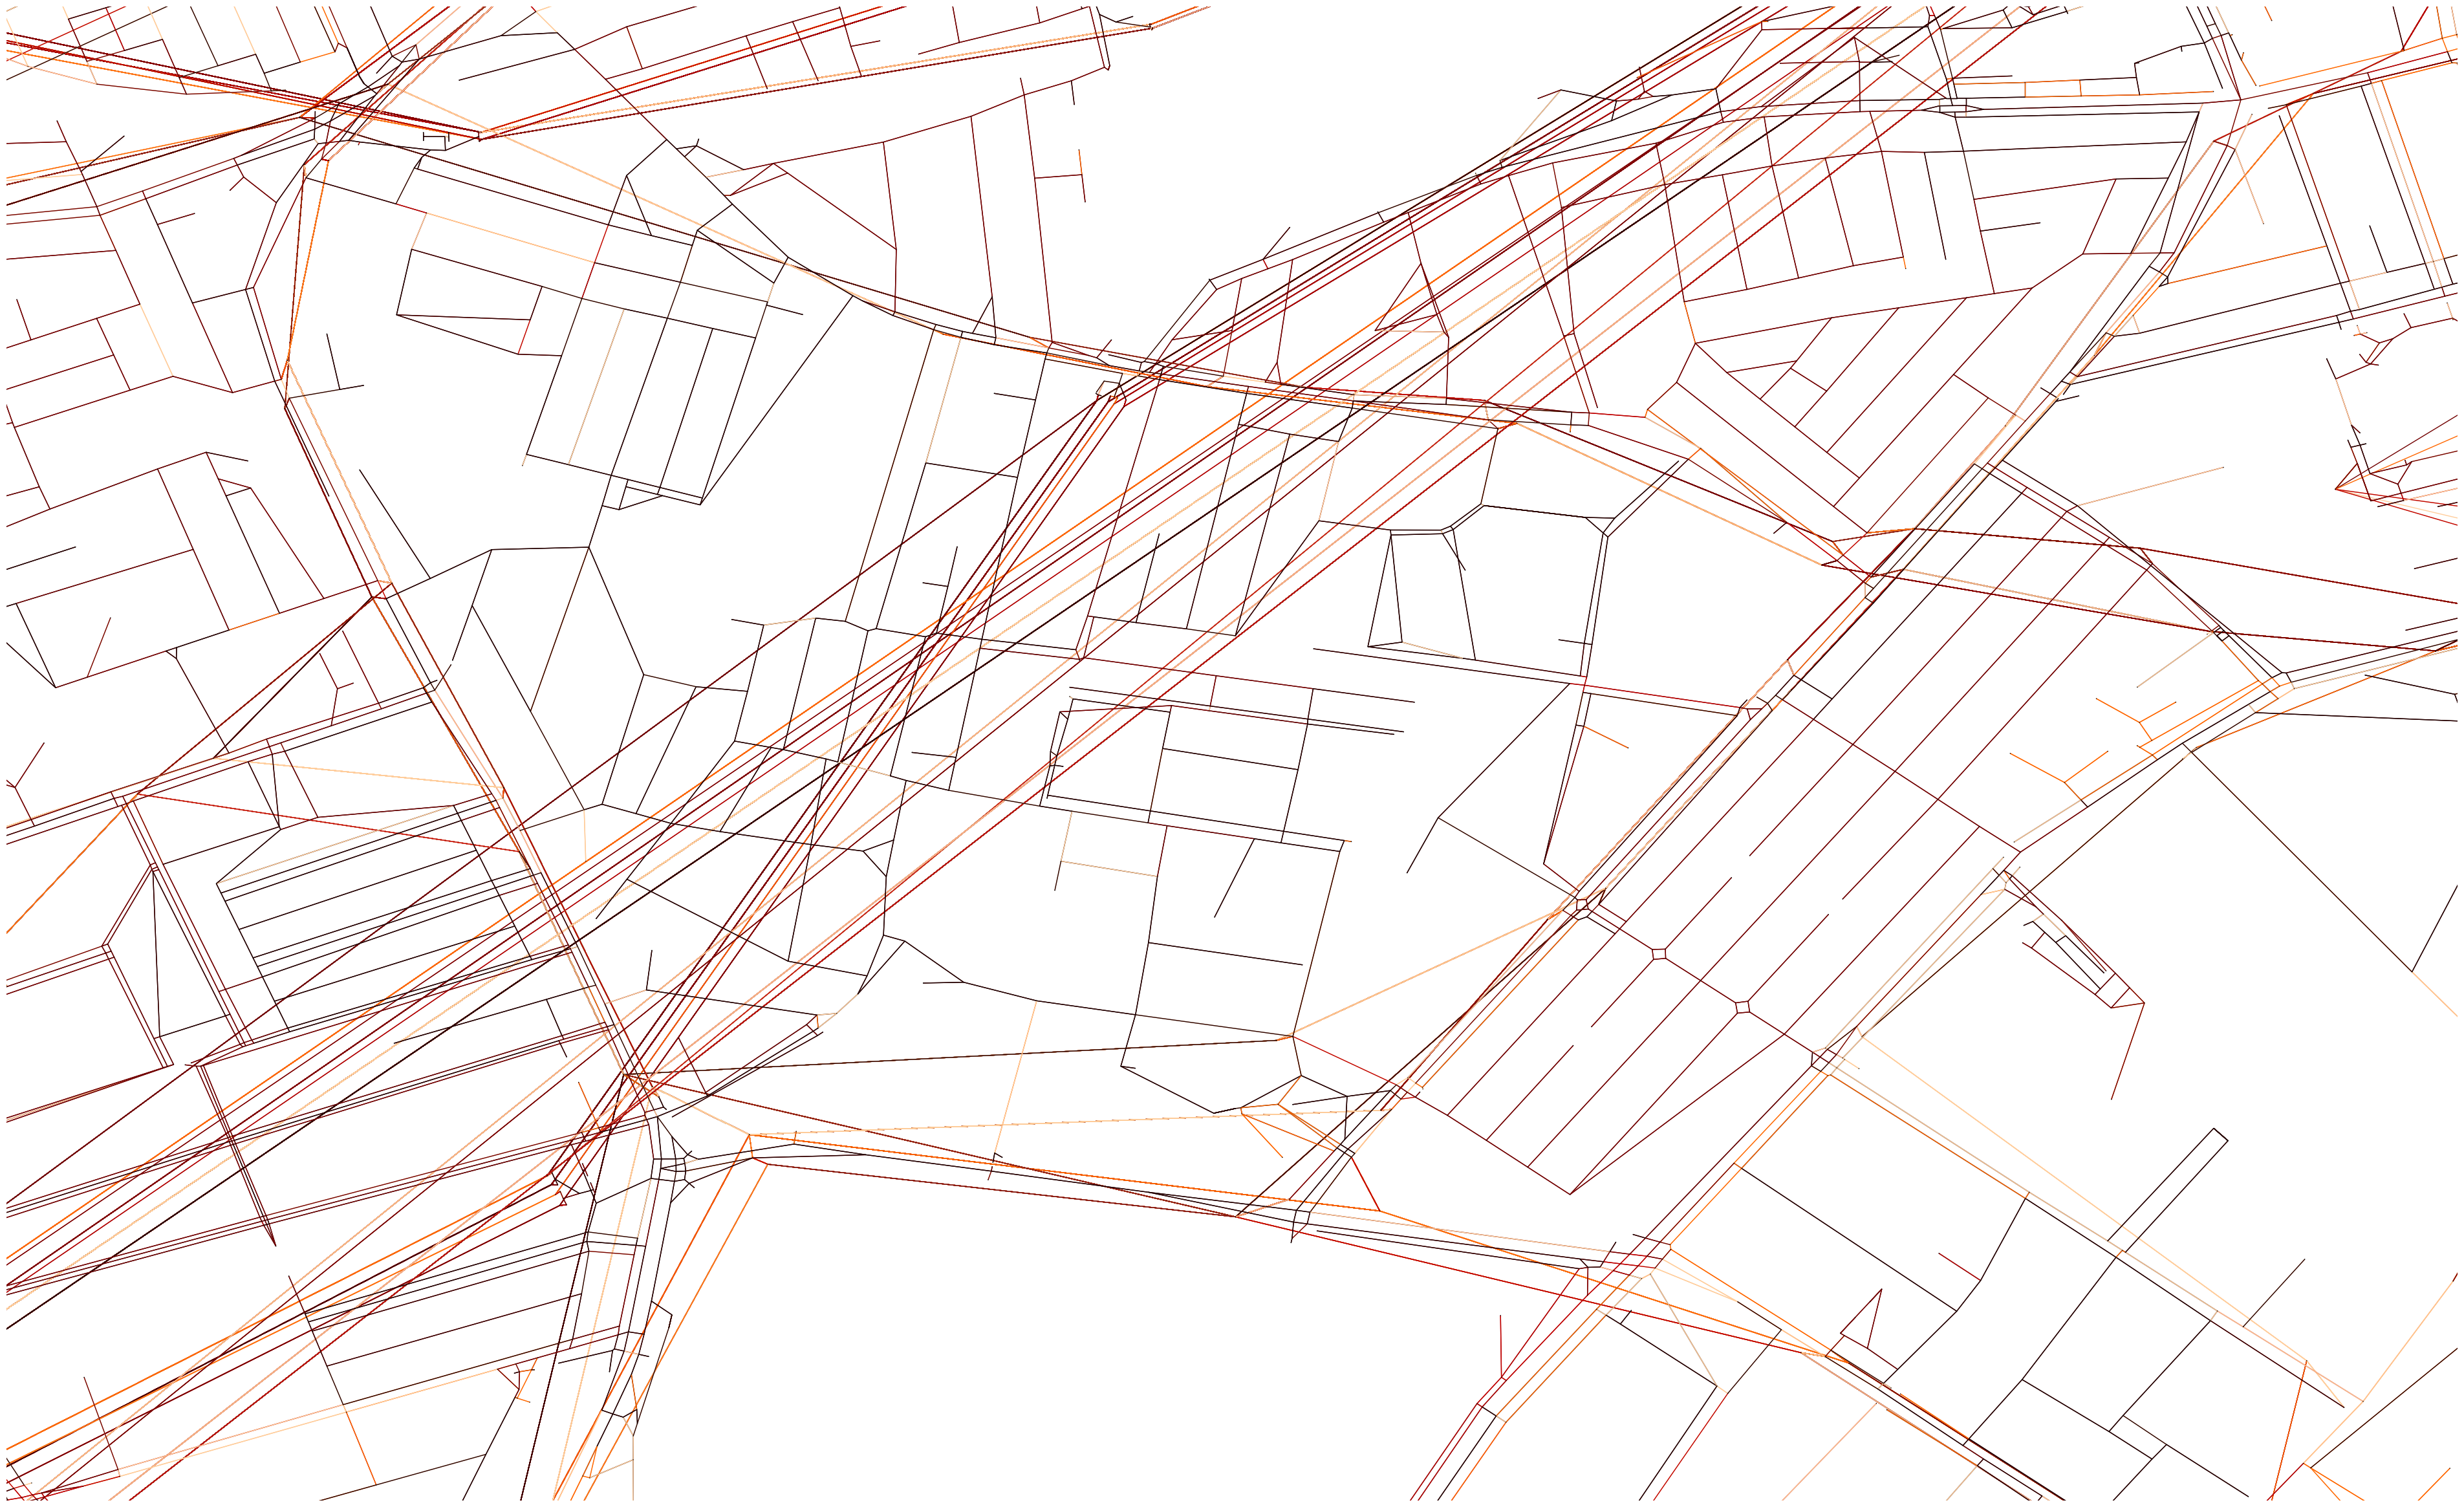

(<Figure size 4890.77x3000 with 1 Axes>, <AxesSubplot: >)

In [29]:
edgecolor = ua.plot.col_colors(df=urbanaccess_net.net_edges, col='weight', cmap='gist_heat_r', num_bins=5)
ua.plot.plot_net(nodes=urbanaccess_net.net_nodes,
                 edges=urbanaccess_net.net_edges,
                 bbox=bbox,
                 fig_height=30, margin=0.02,
                 edge_color=edgecolor, edge_linewidth=1, edge_alpha=1,
                 node_color='black', node_size=1.1, node_alpha=1, node_edgecolor='none', node_zorder=3, nodes_only=False)

In [25]:
urbanaccess_net.net_edges[urbanaccess_net.net_edges['net_type']=='osm to transit']

,weight,unique_agency_id,unique_trip_id,sequence,edge_id,route_type,unique_route_id,net_type,from,to,length,distance,mean,node_id_route,from_int,to_int
1564378,1.717021,nan,nan,NaN,nan,NaN,nan,osm to transit,4688070029,216762_sydney_trains_2-T2-sj2-60_sydney_trains,NaN,NaN,3.364706,216762_sydney_trains_2-T2-sj2-60_sydney_trains,96225,1
1564379,1.717021,nan,nan,NaN,nan,NaN,nan,osm to transit,4688070029,216762_sydney_trains_2-T2-sj2-60_sydney_trains,NaN,NaN,3.364706,216762_sydney_trains_2-T2-sj2-60_sydney_trains,96225,1
1564380,1.717021,nan,nan,NaN,nan,NaN,nan,osm to transit,4688070029,216762_sydney_trains_2-T2-sj2-60_sydney_trains,NaN,NaN,3.364706,216762_sydney_trains_2-T2-sj2-60_sydney_trains,96225,1
1564381,1.717021,nan,nan,NaN,nan,NaN,nan,osm to transit,4688070029,216762_sydney_trains_2-T2-sj2-60_sydney_trains,NaN,NaN,3.364706,216762_sydney_trains_2-T2-sj2-60_sydney_trains,96225,1
1564382,1.717021,nan,nan,NaN,nan,NaN,nan,osm to transit,4688070029,216762_sydney_trains_2-T2-sj2-60_sydney_trains,NaN,NaN,3.364706,216762_sydney_trains_2-T2-sj2-60_sydney_trains,96225,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2340664,0.210607,nan,nan,NaN,nan,NaN,nan,osm to transit,2393269937,2780202_nsw_trainlink_train_76-427-sj2-1_nsw_t...,NaN,NaN,0.250000,2780202_nsw_trainlink_train_76-427-sj2-1_nsw_t...,352873,58713
2340665,0.210607,nan,nan,NaN,nan,NaN,nan,osm to transit,2393269937,2780202_nsw_trainlink_train_76-427-sj2-1_nsw_t...,NaN,NaN,0.250000,2780202_nsw_trainlink_train_76-427-sj2-1_nsw_t...,352873,58713
2340666,0.210607,nan,nan,NaN,nan,NaN,nan,osm to transit,2393269937,2780202_nsw_trainlink_train_76-427-sj2-1_nsw_t...,NaN,NaN,0.250000,2780202_nsw_trainlink_train_76-427-sj2-1_nsw_t...,352873,58713
2340667,0.210607,nan,nan,NaN,nan,NaN,nan,osm to transit,2393269937,2780202_nsw_trainlink_train_76-427-sj2-1_nsw_t...,NaN,NaN,0.250000,2780202_nsw_trainlink_train_76-427-sj2-1_nsw_t...,352873,58713


In [23]:
ua.plot.plot_net(nodes=urbanaccess_net.net_nodes,
                 edges=urbanaccess_net.net_edges[urbanaccess_net.net_edges['net_type']=='transit'],
                 bbox=None,
                 fig_height=30, margin=0.02,
                 edge_color='#999999', edge_linewidth=1, edge_alpha=1,
                 node_color='black', node_size=0, node_alpha=1, node_edgecolor='none', node_zorder=3, nodes_only=False)

SyntaxError: invalid syntax (1232174834.py, line 3)

In [40]:
transit_ped_net.edges_df

,from,to,weight
0,1,2,3.500000
1,2,3,4.200000
2,3,4,2.300000
3,4,5,3.000000
4,5,6,4.000000
...,...,...,...
2340664,352873,58713,0.210607
2340665,352873,58713,0.210607
2340666,352873,58713,0.210607
2340667,352873,58713,0.210607
